In [1]:
import sys
sys.path.insert(0, '../lib')

import anndata as ad
import scanpy as sc
import random
import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

import common_data

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
cell_ids = np.load(common_data.DATA / '08_geneformer-old/embeddings/cell_ids.npy')

In [3]:
cell_ids.size

2175256

In [4]:
embeddings = np.load(common_data.DATA / '08_geneformer-old/embeddings/cell_embeddings.npy')

In [5]:
embeddings.shape

(2175256, 256)

In [6]:
lc_cell_ids = np.load(common_data.DATA / '08_geneformer-old/embeddings/long_covid_cell_ids.npy')

In [7]:
lc_cell_ids.shape

(212785,)

In [8]:
lc_embeddings = np.load(common_data.DATA / '08_geneformer-old/embeddings/long_covid_cell_embeddings.npy')

In [9]:
lc_embeddings.shape

(212785, 256)

In [10]:
cell_ids = np.concatenate([cell_ids, lc_cell_ids])

In [11]:
embeddings = np.vstack([embeddings, lc_embeddings])

In [12]:
cell_ids.shape

(2388041,)

In [13]:
embeddings.shape

(2388041, 256)

In [14]:
sc_meta = pd.read_csv(common_data.SC_META, index_col=0)

/tmp/ipykernel_3246195/1859825940.py:1: DtypeWarning: Columns (16,17,25,31,32,35,37,40,41,52,54,56,57,58,66) have mixed types. Specify dtype option on import or set low_memory=False.
  sc_meta = pd.read_csv(common_data.SC_META, index_col=0)


In [15]:
sc_meta.shape

(2438672, 79)

In [16]:
pd.Series(cell_ids).isin(sc_meta.index).value_counts()

True    2388041
dtype: int64

In [17]:
adata = ad.AnnData(embeddings)
adata.obs_names = cell_ids

In [18]:
adata.obs['cell_type'] = sc_meta['Level_6'][adata.obs_names]
adata.obs['condition'] = sc_meta['perturbation_groups_2'][adata.obs_names]
adata.obs['sample_id'] = sc_meta['individual'][adata.obs_names]
adata.obs['cohort'] = sc_meta['cohort'][adata.obs_names]

In [19]:
adata = adata[adata.obs.cohort.eq('LongCOVID') | adata.obs.condition.ne('discard')].copy()

In [20]:
adata.shape

(1757920, 256)

In [23]:
def add_condition_flags(adata):
    condition_flags = {
        'is_only_virus': ['Early SARS-CoV-2', 'Late SARS-CoV-2'],
        'is_only_bacteria': ['Gram+', 'Gram-*', 'Gram-*; Gram+'],
        'is_healthy': ['Healthy'],
        'is_npc': ['NPC'],
        'is_late_sars': ['Late SARS-CoV-2'],
        'is_early_sars': ['Early SARS-CoV-2'],
    }

    for flag, conditions in condition_flags.items():
        adata.obs[flag] = adata.obs['condition'].isin(conditions).astype(float)

    long_covid_flag = 'is_long_covid'
    long_covid_cohort_labels = ['LongCOVID']

    adata.obs[long_covid_flag] = adata.obs['cohort'].isin(long_covid_cohort_labels).astype(float)

    return adata

In [25]:
def plot_umap_hexbin(ax, adata, C, title, cmap='flare'):
    hb = ax.hexbin(
        x=adata.obsm['X_umap'][:, 0],
        y=adata.obsm['X_umap'][:, 1],
        C=C,
        gridsize=80,
        cmap=cmap,
        ec='none',
        linewidths=0.15
    )

    shrink_by = 0.1
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    xbound = xlim[0] + (xlim[1] - xlim[0]) * shrink_by
    ybound = ylim[0] + (ylim[1] - ylim[0]) * shrink_by

    ax.spines["bottom"].set_bounds(xlim[0], xbound)
    ax.set_xlabel('UMAP1', x=0, ha="left")
    ax.plot(xbound, 0, ">k", transform=ax.get_xaxis_transform(), clip_on=False)

    ax.spines["left"].set_bounds(ylim[0], ybound)
    ax.set_ylabel('UMAP2', y=0, ha="left")
    ax.plot(0, ybound, "^k", transform=ax.get_yaxis_transform(), clip_on=False)

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    ax.tick_params(left=False, labelleft=False, bottom=False, labelbottom=False)

    norm = plt.Normalize(0, 1)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    # Position colorbar at bottom right of each subplot
    cax = ax.inset_axes([0.6, -0.15, 0.35, 0.05])  # Relative to the axis

    ax.figure.colorbar(
        sm,
        cax=cax,
        label=f'Proportion\nof {title}',
        orientation='horizontal',
        ticks=[0, 0.5, 1]
    )

    ax.set_title(title)
    hb.set_rasterized(True)


In [26]:
def plot_conditions_hexbin(adata, save_path=None, fig_title=None):
    fig, axes = plt.subplots(2, 3, figsize=(8, 8), constrained_layout=True)

    plots = [
        ('is_early_sars', 'Early SARS-Cov-2', (0, 0)),
        ('is_late_sars', 'Late SARS-Cov-2', (0, 1)),
        ('is_only_bacteria', 'Bacteria', (0, 2)),
        ('is_healthy', 'Healthy', (1, 0)),
        ('is_npc', 'NPC', (1, 1)),
        ('is_long_covid', 'LongCovid', (1, 2)),
    ]

    for key, title, (i, j) in plots:
        plot_umap_hexbin(axes[i, j], adata, adata.obs[key], title)

    #fig.delaxes(axes[1, 2])  # Remove the empty subplot

    if fig_title:
        fig.suptitle(fig_title, fontsize=20)

    if save_path:
        fig.savefig(save_path, dpi=300)
        plt.close(fig)  # Close the figure if saving
    else:
        plt.show()


### Visualization of all of the cell types

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


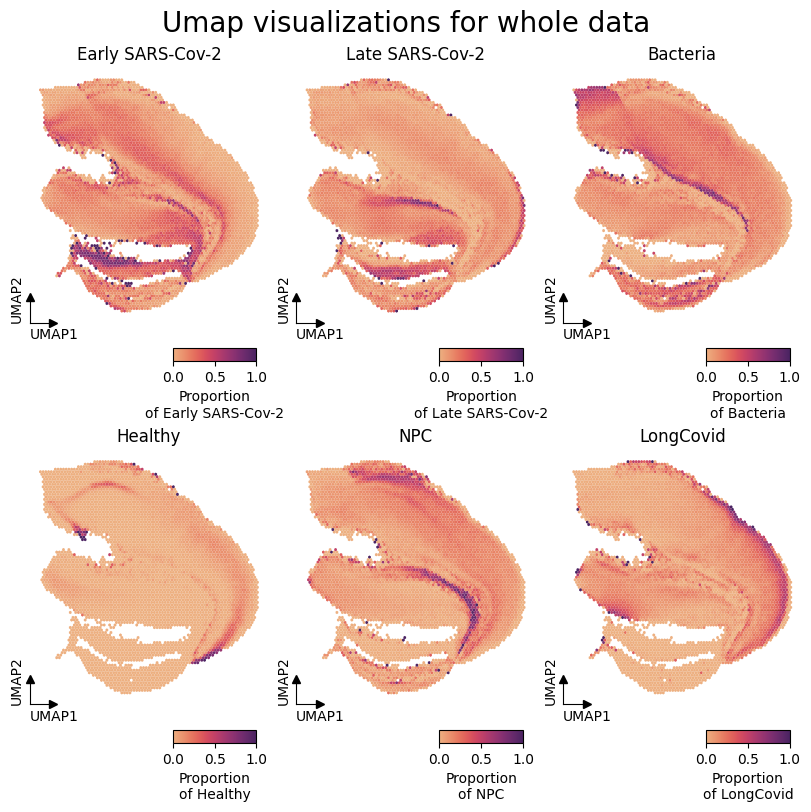

DONE


In [27]:
sc.tl.pca(adata, n_comps=50, random_state = 111)
sc.pp.neighbors(adata, use_rep='X_pca', random_state = 111)
sc.tl.umap(adata, random_state = 111)

adata = add_condition_flags(adata)
plot_conditions_hexbin(adata, fig_title=f"Umap visualizations for whole data")
print('DONE')

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


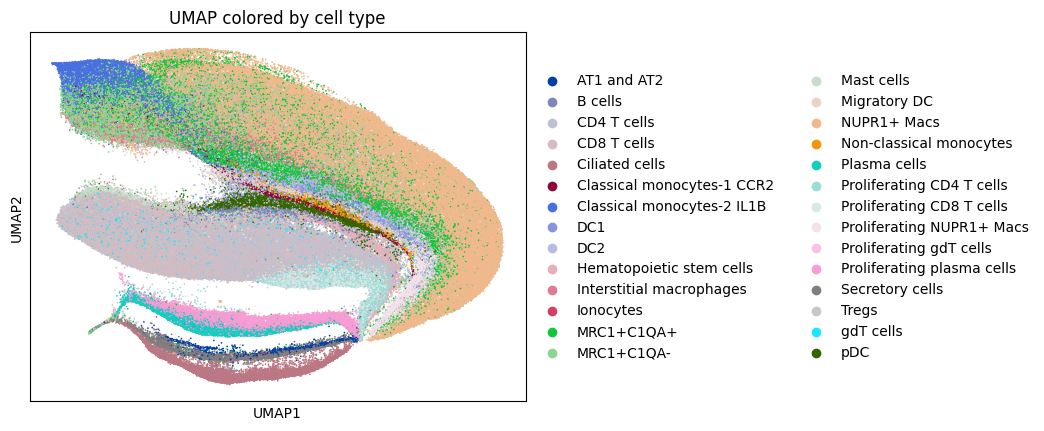

In [28]:
# Plot UMAP
sc.pl.umap(
    adata,
    color=['cell_type'],
    title=['UMAP colored by cell type'],
    size = 6,
)

In [29]:
adata.write_h5ad(common_data.DATA / '08_geneformer/embeddings/embeddings.h5ad')